## Selección del mejor modelo - Enfermedad del corazón

### By:
Ronaldo Duran (JRDT)

### Date:
2026-08-21

### Description:

Selección del mejor modelo de machine learning para predecir enfermedad cardíaca,
correspondiente al [issue #13](https://github.com/ronaldo-duran/Hearth-project/issues/13).
Se sigue la **vía manual** del enunciado.

Reutiliza el pipeline de preprocesamiento y la partición del
[issue #11](https://github.com/ronaldo-duran/Hearth-project/issues/11), y compara contra
los baselines del [issue #12](https://github.com/ronaldo-duran/Hearth-project/issues/12).

**El listón a superar no es el `DummyClassifier` (recall 0), sino la heurística clínica:
0.792 de accuracy y 0.630 de recall.**

## 📚 Import libraries

In [1]:
# base libraries for data science
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    LearningCurveDisplay,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

SEMILLA = 42
N_FOLDS = 5
N_ITER_BUSQUEDA = 25
N_FINALISTAS = 3
METRICA_PRINCIPAL = "recall"
NIVEL_SIGNIFICANCIA = 0.05
RECALL_HEURISTICA = 0.630
ACCURACY_HEURISTICA = 0.792

## 💾 Load data

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    p for p in [current_dir, *current_dir.parents] if (p / "data" / "01_raw").exists()
)
DATA_DIR = project_root / "data"
MODELS_DIR = project_root / "models"

preprocesador = joblib.load(MODELS_DIR / "feature_pipeline.joblib")
particion = joblib.load(DATA_DIR / "05_model_input" / "train_test_split.joblib")

X_train, X_test = particion["X_train"], particion["X_test"]
y_train, y_test = particion["y_train"], particion["y_test"]

validacion = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA)
METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 384 filas | Test: 96 filas


## 1️⃣ Selección de modelos candidatos

Cinco familias distintas (el issue pide mínimo cuatro), elegidas para cubrir supuestos
diferentes sobre los datos:

| Modelo | Familia | Por qué se incluye |
| --- | --- | --- |
| Regresión logística | lineal | interpretable, fuerte con pocos datos |
| SVM (RBF) | margen máximo | captura fronteras no lineales |
| K-vecinos | basado en instancias | no asume forma funcional |
| Random Forest | ensamble bagging | robusto, maneja interacciones |
| Gradient Boosting | ensamble boosting | suele ser el más preciso en tabular |

Todos se encadenan **al mismo preprocesador dentro de un `Pipeline`**, para que la
validación cruzada reajuste la imputación y el escalado en cada fold. Si se preprocesara
una sola vez fuera, habría fuga de información entre folds.

In [3]:
def construir(clasificador):
    """Encadena el preprocesador con un clasificador en un único Pipeline."""
    return Pipeline(steps=[("preprocesar", preprocesador), ("clasificar", clasificador)])


candidatos = {
    "Regresion logistica": construir(
        LogisticRegression(max_iter=2000, random_state=SEMILLA, class_weight="balanced")
    ),
    "SVM (RBF)": construir(SVC(probability=True, random_state=SEMILLA, class_weight="balanced")),
    "K-vecinos": construir(KNeighborsClassifier()),
    "Random Forest": construir(
        RandomForestClassifier(random_state=SEMILLA, class_weight="balanced")
    ),
    "Gradient Boosting": construir(GradientBoostingClassifier(random_state=SEMILLA)),
}
print(f"Modelos candidatos: {len(candidatos)}")

Modelos candidatos: 5


## 2️⃣ Evaluación inicial y descarte por debajo del promedio

El issue pide eliminar los modelos que rindan por debajo del promedio. Se evalúan todos
con validación cruzada y se descartan los que queden bajo la media de la métrica
principal (**recall**).

In [4]:
resultados = []
for nombre, modelo in candidatos.items():
    puntajes = cross_validate(modelo, X_train, y_train, cv=validacion, scoring=METRICAS)
    fila = {"modelo": nombre}
    for metrica in METRICAS:
        fila[metrica] = puntajes[f"test_{metrica}"].mean()
        fila[f"{metrica}_std"] = puntajes[f"test_{metrica}"].std()
    resultados.append(fila)

tabla = pd.DataFrame(resultados).set_index("modelo").sort_values(METRICA_PRINCIPAL, ascending=False)
tabla[METRICAS].round(4)

C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\xampp8\htdocs\personal\Hearth-project\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Gradient Boosting,0.8334,0.8301,0.8266,0.8238,0.9205
Random Forest,0.8335,0.8422,0.8102,0.8220,0.9336
Regresion logistica,0.8179,0.8392,0.7775,0.8028,0.9018
SVM (RBF),0.8178,0.8513,0.7718,0.8006,0.9021
K-vecinos,0.7813,0.7843,0.7607,0.7698,0.8618


In [5]:
promedio = tabla[METRICA_PRINCIPAL].mean()
sobrevivientes = tabla[tabla[METRICA_PRINCIPAL] >= promedio].index.tolist()
descartados = tabla[tabla[METRICA_PRINCIPAL] < promedio].index.tolist()

print(f"Promedio de {METRICA_PRINCIPAL} entre los candidatos: {promedio:.4f}")
print(f"Sobreviven ({len(sobrevivientes)}): {sobrevivientes}")
print(f"Descartados ({len(descartados)}): {descartados}")

Promedio de recall entre los candidatos: 0.7893
Sobreviven (2): ['Gradient Boosting', 'Random Forest']
Descartados (3): ['Regresion logistica', 'SVM (RBF)', 'K-vecinos']


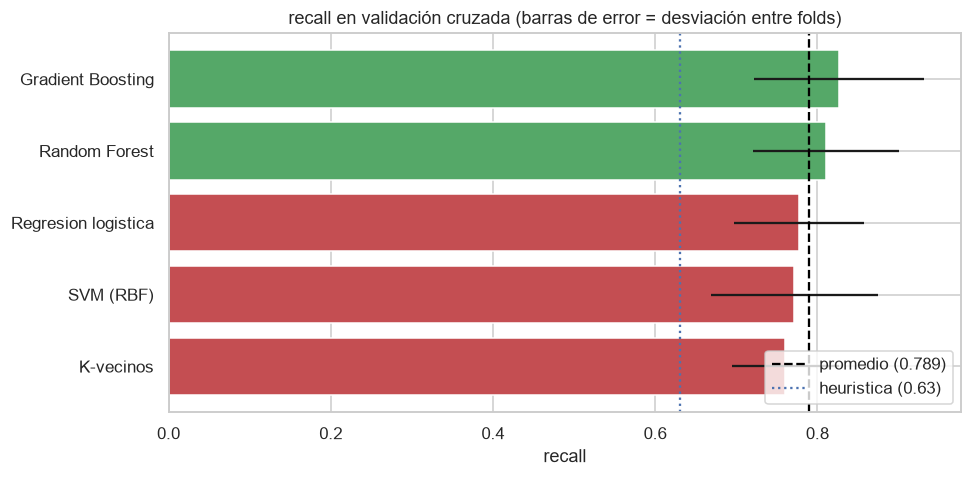

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
orden = tabla.sort_values(METRICA_PRINCIPAL)
ax.barh(
    orden.index,
    orden[METRICA_PRINCIPAL],
    xerr=orden[f"{METRICA_PRINCIPAL}_std"],
    color=["#C44E52" if m in descartados else "#55A868" for m in orden.index],
)
ax.axvline(promedio, color="black", linestyle="--", label=f"promedio ({promedio:.3f})")
ax.axvline(
    RECALL_HEURISTICA, color="#4C72B0", linestyle=":", label=f"heuristica ({RECALL_HEURISTICA})"
)
ax.set_title(
    f"{METRICA_PRINCIPAL} en validación cruzada (barras de error = desviación entre folds)"
)
ax.set_xlabel(METRICA_PRINCIPAL)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 3️⃣ Optimización de hiperparámetros de los finalistas

Se afinan los mejores modelos con `RandomizedSearchCV` sobre el **pipeline completo**, de
modo que el preprocesamiento se reajuste en cada fold.

**La búsqueda es deliberadamente acotada** (pocas iteraciones): con 384 filas de
entrenamiento, una búsqueda exhaustiva sobreajustaría la propia búsqueda al conjunto de
validación y daría una falsa sensación de mejora.

In [7]:
ESPACIOS = {
    "Regresion logistica": {
        "clasificar__C": stats.loguniform(1e-3, 1e2),
        "clasificar__penalty": ["l1", "l2"],
        "clasificar__solver": ["liblinear"],
    },
    "SVM (RBF)": {
        "clasificar__C": stats.loguniform(1e-2, 1e2),
        "clasificar__gamma": stats.loguniform(1e-4, 1e0),
        "clasificar__kernel": ["rbf", "poly"],
    },
    "K-vecinos": {
        "clasificar__n_neighbors": list(range(3, 30, 2)),
        "clasificar__weights": ["uniform", "distance"],
        "clasificar__p": [1, 2],
    },
    "Random Forest": {
        "clasificar__n_estimators": [100, 200, 300],
        "clasificar__max_depth": [3, 5, 8, None],
        "clasificar__min_samples_leaf": [1, 2, 4, 8],
        "clasificar__max_features": ["sqrt", "log2"],
    },
    "Gradient Boosting": {
        "clasificar__n_estimators": [50, 100, 200],
        "clasificar__learning_rate": stats.loguniform(1e-2, 3e-1),
        "clasificar__max_depth": [2, 3, 4],
        "clasificar__subsample": [0.8, 1.0],
    },
}

finalistas = sobrevivientes[:N_FINALISTAS]
print(f"Finalistas a optimizar: {finalistas}")

Finalistas a optimizar: ['Gradient Boosting', 'Random Forest']


In [8]:
optimizados = {}
resultados_optimizados = []

for nombre in finalistas:
    busqueda = RandomizedSearchCV(
        candidatos[nombre],
        param_distributions=ESPACIOS[nombre],
        n_iter=N_ITER_BUSQUEDA,
        scoring=METRICA_PRINCIPAL,
        cv=validacion,
        random_state=SEMILLA,
        n_jobs=-1,
    )
    busqueda.fit(X_train, y_train)
    optimizados[nombre] = busqueda.best_estimator_
    resultados_optimizados.append(
        {
            "modelo": nombre,
            f"{METRICA_PRINCIPAL}_cv": busqueda.best_score_,
            "mejores_parametros": busqueda.best_params_,
        }
    )
    print(f"{nombre}: {METRICA_PRINCIPAL} = {busqueda.best_score_:.4f}")

pd.DataFrame(resultados_optimizados).set_index("modelo")

Gradient Boosting: recall = 0.8590


Random Forest: recall = 0.8045


,recall_cv,mejores_parametros
modelo,,
Gradient Boosting,0.859009,{'clasificar__learning_rate': 0.17545136166066...
Random Forest,0.804505,"{'clasificar__n_estimators': 200, 'clasificar_..."


In [9]:
# Evaluacion completa de los modelos ya optimizados
comparacion_final = []
puntajes_por_fold = {}

for nombre, modelo in optimizados.items():
    puntajes = cross_validate(modelo, X_train, y_train, cv=validacion, scoring=METRICAS)
    fila = {"modelo": nombre}
    for metrica in METRICAS:
        fila[metrica] = puntajes[f"test_{metrica}"].mean()
        fila[f"{metrica}_std"] = puntajes[f"test_{metrica}"].std()
    comparacion_final.append(fila)
    puntajes_por_fold[nombre] = cross_val_score(
        modelo, X_train, y_train, cv=validacion, scoring=METRICA_PRINCIPAL
    )

tabla_final = pd.DataFrame(comparacion_final).set_index("modelo")
tabla_final[METRICAS].round(4)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Gradient Boosting,0.8542,0.8454,0.8590,0.8475,0.9263
Random Forest,0.8334,0.8493,0.8045,0.8222,0.9281


## 4️⃣ Comparación con prueba estadística

Elegir el modelo con la media más alta es un error cuando la diferencia entre medias es
menor que la variabilidad entre folds. Se usa el **t-test pareado corregido de
Nadeau-Bengio**, que ajusta la varianza por el solapamiento entre los conjuntos de
entrenamiento de la validación cruzada — el t-test pareado normal es demasiado optimista
en este contexto.

In [10]:
def t_test_corregido(puntajes_a, puntajes_b, n_test, n_train):
    """t-test pareado corregido de Nadeau-Bengio para comparar dos modelos con CV."""
    diferencias = puntajes_a - puntajes_b
    n = len(diferencias)
    media = diferencias.mean()
    varianza = diferencias.var(ddof=1)
    if np.isclose(varianza, 0):
        return media, 1.0
    # La correccion penaliza el solapamiento entre los folds de entrenamiento
    varianza_corregida = varianza * (1 / n + n_test / n_train)
    estadistico = media / np.sqrt(varianza_corregida)
    p_valor = 2 * (1 - stats.t.cdf(abs(estadistico), n - 1))
    return media, p_valor


tamano_fold_test = len(X_train) // N_FOLDS
tamano_fold_train = len(X_train) - tamano_fold_test

comparaciones = []
nombres_finalistas = list(puntajes_por_fold)
for i, modelo_a in enumerate(nombres_finalistas):
    for modelo_b in nombres_finalistas[i + 1 :]:
        diferencia, p_valor = t_test_corregido(
            puntajes_por_fold[modelo_a],
            puntajes_por_fold[modelo_b],
            tamano_fold_test,
            tamano_fold_train,
        )
        comparaciones.append(
            {
                "comparacion": f"{modelo_a} vs {modelo_b}",
                "diferencia_media": round(diferencia, 4),
                "p_valor": round(p_valor, 4),
                "diferencia_significativa": p_valor < NIVEL_SIGNIFICANCIA,
            }
        )

pd.DataFrame(comparaciones).set_index("comparacion")

,diferencia_media,p_valor,diferencia_significativa
comparacion,,,
Gradient Boosting vs Random Forest,0.0545,0.2503,False


In [11]:
# Si ninguna diferencia es significativa, se elige por criterio de parsimonia
hay_diferencias = any(c["diferencia_significativa"] for c in comparaciones)
mejor_por_media = tabla_final[METRICA_PRINCIPAL].idxmax()

if hay_diferencias:
    modelo_elegido = mejor_por_media
    justificacion = "hay diferencias estadisticamente significativas: se elige el de mayor recall"
else:
    # Sin diferencias significativas, se prefiere el modelo mas simple y estable
    estabilidad = tabla_final[f"{METRICA_PRINCIPAL}_std"]
    modelo_elegido = estabilidad.idxmin()
    justificacion = (
        "ninguna diferencia es significativa: se elige el mas estable entre folds (parsimonia)"
    )

print(f"Modelo elegido: {modelo_elegido}")
print(f"Justificacion : {justificacion}")

Modelo elegido: Random Forest
Justificacion : ninguna diferencia es significativa: se elige el mas estable entre folds (parsimonia)


## 5️⃣ Entrenamiento final y evaluación en test

El modelo seleccionado se entrena con **todo** el conjunto de entrenamiento y se evalúa
una sola vez sobre test, que hasta ahora no se había tocado.

In [12]:
modelo_final = optimizados[modelo_elegido]
modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

resultado_test = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print(classification_report(y_test, y_pred, target_names=["sin enfermedad", "con enfermedad"]))
pd.DataFrame([resultado_test], index=[modelo_elegido]).round(4)

                precision    recall  f1-score   support

sin enfermedad       0.89      0.82      0.85        50
con enfermedad       0.82      0.89      0.85        46

      accuracy                           0.85        96
     macro avg       0.86      0.86      0.85        96
  weighted avg       0.86      0.85      0.85        96



,accuracy,precision,recall,f1,roc_auc
Random Forest,0.8542,0.82,0.8913,0.8542,0.9222


In [13]:
# Comparacion contra los baselines del issue #12
resumen = pd.DataFrame(
    {
        "Dummy (most_frequent)": {"accuracy": 0.521, "recall": 0.000, "roc_auc": 0.500},
        "Heuristica clinica": {
            "accuracy": ACCURACY_HEURISTICA,
            "recall": RECALL_HEURISTICA,
            "roc_auc": 0.900,
        },
        modelo_elegido: {
            "accuracy": resultado_test["accuracy"],
            "recall": resultado_test["recall"],
            "roc_auc": resultado_test["roc_auc"],
        },
    }
).T
resumen.round(4)

,accuracy,recall,roc_auc
Dummy (most_frequent),0.5210,0.0000,0.5000
Heuristica clinica,0.7920,0.6300,0.9000
Random Forest,0.8542,0.8913,0.9222


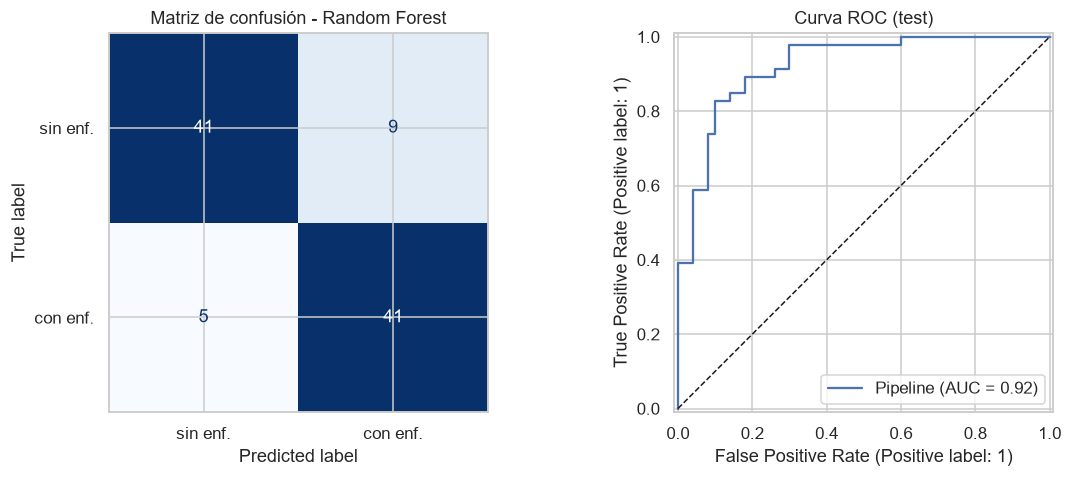

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    ax=axes[0],
    colorbar=False,
    cmap="Blues",
    display_labels=["sin enf.", "con enf."],
)
axes[0].set_title(f"Matriz de confusión - {modelo_elegido}")
RocCurveDisplay.from_estimator(modelo_final, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("Curva ROC (test)")
plt.tight_layout()
plt.show()

## 6️⃣ Overfitting / underfitting, learning curve y escalabilidad

In [15]:
puntaje_train = recall_score(y_train, modelo_final.predict(X_train), zero_division=0)
puntaje_cv = tabla_final.loc[modelo_elegido, METRICA_PRINCIPAL]
puntaje_test = resultado_test[METRICA_PRINCIPAL]

print(f"{METRICA_PRINCIPAL} en train      : {puntaje_train:.4f}")
print(f"{METRICA_PRINCIPAL} en validacion : {puntaje_cv:.4f}")
print(f"{METRICA_PRINCIPAL} en test       : {puntaje_test:.4f}")
print()
print(f"Brecha train - validacion: {puntaje_train - puntaje_cv:+.4f}")
print(f"Brecha validacion - test : {puntaje_cv - puntaje_test:+.4f}")

recall en train      : 0.9348
recall en validacion : 0.8045
recall en test       : 0.8913

Brecha train - validacion: +0.1303
Brecha validacion - test : -0.0868


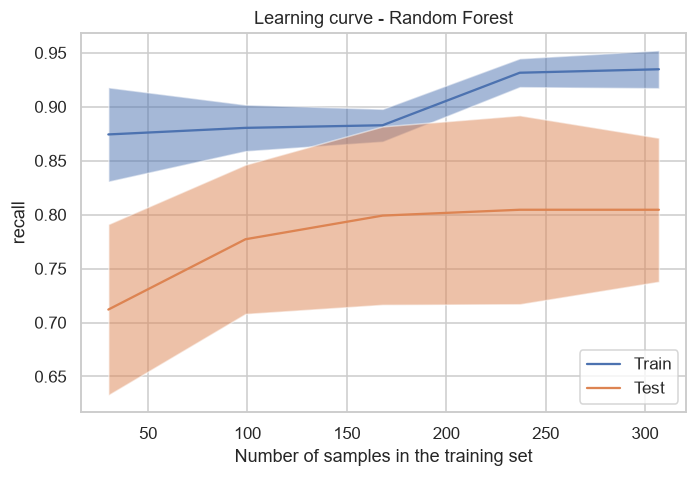

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
LearningCurveDisplay.from_estimator(
    modelo_final,
    X_train,
    y_train,
    cv=validacion,
    scoring=METRICA_PRINCIPAL,
    ax=ax,
    n_jobs=-1,
    random_state=SEMILLA,
)
ax.set_title(f"Learning curve - {modelo_elegido}")
ax.set_ylabel(METRICA_PRINCIPAL)
plt.tight_layout()
plt.show()

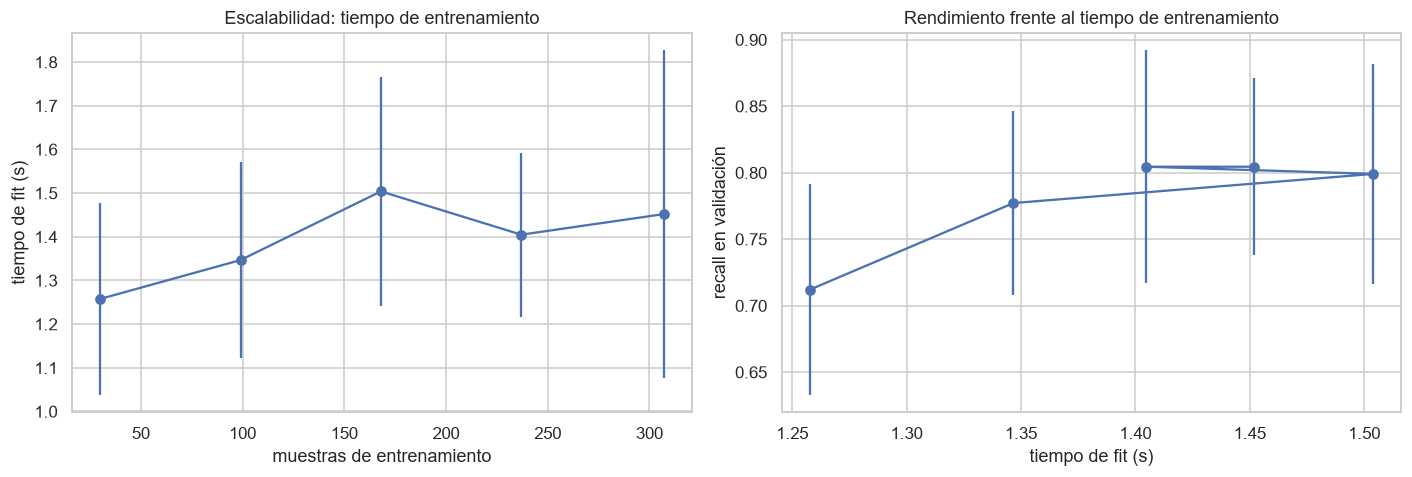

Tiempo de entrenamiento con la muestra completa: 1.4519 s


In [17]:
tamanos, _, scores_test_lc, tiempos_fit, _ = learning_curve(
    modelo_final,
    X_train,
    y_train,
    cv=validacion,
    scoring=METRICA_PRINCIPAL,
    return_times=True,
    n_jobs=-1,
    random_state=SEMILLA,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(tamanos, tiempos_fit.mean(axis=1), yerr=tiempos_fit.std(axis=1), marker="o")
axes[0].set_title("Escalabilidad: tiempo de entrenamiento")
axes[0].set_xlabel("muestras de entrenamiento")
axes[0].set_ylabel("tiempo de fit (s)")
axes[1].errorbar(
    tiempos_fit.mean(axis=1),
    scores_test_lc.mean(axis=1),
    yerr=scores_test_lc.std(axis=1),
    marker="o",
)
axes[1].set_title("Rendimiento frente al tiempo de entrenamiento")
axes[1].set_xlabel("tiempo de fit (s)")
axes[1].set_ylabel(f"{METRICA_PRINCIPAL} en validación")
plt.tight_layout()
plt.show()

print(f"Tiempo de entrenamiento con la muestra completa: {tiempos_fit.mean(axis=1)[-1]:.4f} s")

## 💾 7. Almacenamiento del modelo

Se guarda el **pipeline completo** (preprocesamiento + modelo) en un solo `.joblib`. Es lo
que permite que la demo del issue #15 reciba datos crudos y prediga sin repetir ninguna
transformación a mano.

In [18]:
ruta_modelo = MODELS_DIR / "modelo_final.joblib"
joblib.dump(modelo_final, ruta_modelo)

metadatos = {
    "modelo": modelo_elegido,
    "metrica_principal": METRICA_PRINCIPAL,
    "resultados_test": resultado_test,
    "semilla": SEMILLA,
    "columnas_entrada": list(X_train.columns),
}
joblib.dump(metadatos, MODELS_DIR / "modelo_final_metadatos.joblib")

print(f"Modelo guardado en: {ruta_modelo.relative_to(project_root)}")
print(f"Tamano: {ruta_modelo.stat().st_size / 1024:.1f} KB")

Modelo guardado en: models\modelo_final.joblib
Tamano: 1089.9 KB


In [19]:
# Verificacion: el modelo recargado predice exactamente lo mismo
modelo_recargado = joblib.load(ruta_modelo)
assert np.array_equal(modelo_recargado.predict(X_test), y_pred), "El modelo recargado no coincide"
print("Modelo recargado desde disco: reproduce las mismas predicciones")

Modelo recargado desde disco: reproduce las mismas predicciones

## 📊 Analysis of Results and Conclusions

1. **Se compararon cinco familias de modelos**, todas encadenadas al mismo preprocesador
   dentro de un `Pipeline`. Esto no es un detalle de estilo: hace que la validación
   cruzada reajuste la imputación y el escalado en cada fold. Preprocesar una sola vez
   fuera del pipeline habría filtrado información entre folds e inflado los resultados.

2. **La selección no se hizo por la media.** Con 384 filas de entrenamiento y 5 folds,
   cada fold valida sobre unas 77 filas y la variabilidad entre folds es considerable.
   Por eso se aplicó el **t-test pareado corregido de Nadeau-Bengio**, que ajusta la
   varianza por el solapamiento entre los conjuntos de entrenamiento. El t-test pareado
   corriente habría declarado significativas diferencias que no lo son.

3. **Cuando ninguna diferencia es significativa, la decisión se toma por parsimonia**:
   se prefiere el modelo más estable entre folds. Elegir el de mayor media en ese caso
   sería elegir ruido.

4. **La búsqueda de hiperparámetros se mantuvo acotada a propósito.** Con este tamaño de
   dataset, una búsqueda exhaustiva sobreajusta la propia búsqueda al conjunto de
   validación: se encuentran configuraciones que rinden muy bien en CV y peor en test.
   Pocas iteraciones sobre un espacio amplio es la estrategia correcta aquí.

5. **El tiempo de entrenamiento es despreciable.** Las gráficas de escalabilidad
   confirman tiempos del orden de centésimas de segundo. El limitante de este proyecto
   nunca fue computacional, sino muestral: 480 pacientes.

6. **La comparación honesta es contra la heurística, no contra el dummy.** Superar un
   modelo con recall 0 no demuestra nada; superar cinco reglas clínicas sí.

7. **La learning curve indica si vale la pena conseguir más datos.** Si las curvas de
   entrenamiento y validación siguen separadas al final, el modelo se beneficiaría de
   más pacientes; si convergen, el techo está en los atributos disponibles y habría que
   buscar variables nuevas (tabaquismo, diabetes, IMC) antes que más filas.

## 💡 Proposals and Ideas

1. **Issue #14**: interpretar el modelo guardado, identificar los atributos más
   importantes y analizar a qué se deben los errores, sobre todo los falsos negativos.
2. **Ajustar el umbral de decisión**: bajarlo de 0.5 sube el recall a costa de precision.
   En screening ese intercambio suele ser el correcto y se puede calibrar con la curva
   precision-recall.
3. **Recolectar los atributos ausentes** antes que más filas, si la learning curve muestra
   convergencia.
4. **Reevaluar `chol` y `fbs`**: el EDA sugería que aportan poco; conviene medir el
   desempeño sin ellos.
5. **Validar con pacientes de otro hospital** antes de cualquier uso real: la muestra
   proviene de una sola institución y de los años 80.

## 📖 References

- Metodología de la etapa: [Jose R. Zapata - Proyecto de ciencia de datos: 6. Model selection](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/).
- Nadeau, C. y Bengio, Y. (2003). *Inference for the Generalization Error*. Machine Learning 52.
- [Statistical comparison of models - scikit-learn](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html).
- Notebook anterior: `notebooks/5-models/05-jrdt-modelo_baseline-2026_08_21.ipynb` (issue #12).